# Notebook 3: Analyzing Data

Now let's find insights in our data!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/sales.csv')

# Calculate total sales
df['total'] = df['quantity'] * df['price']
df

,date,product,quantity,price,region,total
0,2024-01-15,Laptop,2,1000,North,2000
1,2024-01-16,Mouse,5,25,South,125
2,2024-01-17,Keyboard,3,75,East,225
3,2024-01-18,Monitor,1,400,West,400
4,2024-01-19,Laptop,1,1000,North,1000
5,2024-01-20,Mouse,10,25,South,250
6,2024-01-21,Keyboard,2,75,East,150
7,2024-01-22,Monitor,2,400,West,800


## 1. Group and Aggregate

In [2]:
# Total sales by product
df.groupby('product')['total'].sum()

product
Keyboard     375
Laptop      3000
Monitor     1200
Mouse        375
Name: total, dtype: int64

In [3]:
# Average price by region
df.groupby('region')['price'].mean()

region
East       75.0
North    1000.0
South      25.0
West      400.0
Name: price, dtype: float64

In [4]:
# Multiple calculations at once
df.groupby('product').agg({
    'quantity': 'sum',
    'total': ['sum', 'mean']
})

quantity total        
              sum   sum    mean
product                        
Keyboard        5   375   187.5
Laptop          3  3000  1500.0
Monitor         3  1200   600.0
Mouse          15   375   187.5

## 2. Simple Visualization

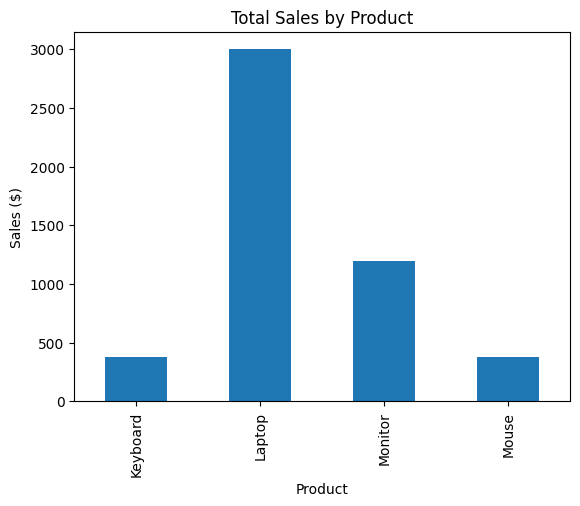

In [5]:
# Bar chart of sales by product
sales_by_product = df.groupby('product')['total'].sum()
sales_by_product.plot(kind='bar')
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Sales ($)')
plt.show()

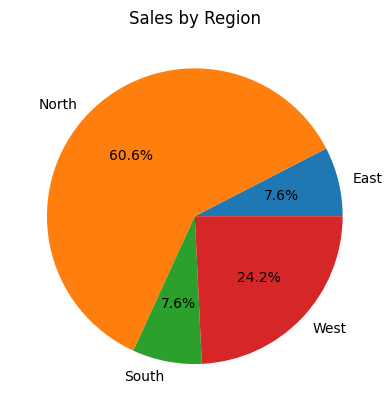

In [6]:
# Sales by region
sales_by_region = df.groupby('region')['total'].sum()
sales_by_region.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Region')
plt.show()

## 3. Sorting and Ranking

In [7]:
# Sort by total sales (highest first)
df_sorted = df.sort_values('total', ascending=False)
df_sorted

,date,product,quantity,price,region,total
0,2024-01-15,Laptop,2,1000,North,2000
4,2024-01-19,Laptop,1,1000,North,1000
7,2024-01-22,Monitor,2,400,West,800
3,2024-01-18,Monitor,1,400,West,400
5,2024-01-20,Mouse,10,25,South,250
2,2024-01-17,Keyboard,3,75,East,225
6,2024-01-21,Keyboard,2,75,East,150
1,2024-01-16,Mouse,5,25,South,125


In [8]:
# Top 3 sales
df_sorted.head(3)

,date,product,quantity,price,region,total
0,2024-01-15,Laptop,2,1000,North,2000
4,2024-01-19,Laptop,1,1000,North,1000
7,2024-01-22,Monitor,2,400,West,800


## 🎯 Practice Exercises

1. Find total sales by region
2. Find the product with highest average price
3. Create a bar chart of quantity sold by product
4. Find which region has the highest total sales
5. Calculate the profit if each product has 40% cost (profit = total × 0.6)